In [ ]:
import os
import pandas as pd
from dotenv import load_dotenv
from supabase import create_client

# 1. Load credentials from .env
load_dotenv()

url = os.getenv("SUPABASE_URL")
key = os.getenv("SUPABASE_KEY")

# 2. Connect to Supabase
supabase = create_client(url, key)

# 3. Fetch first 5 rows from telco_churn
all_rows = []
step = 1000
start = 0

while True:
    res = (
        supabase.table("telco_churn")
        .select("*")
        .range(start, start + step - 1)
        .execute()
    )
    if not res.data:
        break
    all_rows.extend(res.data)
    start += step

df = pd.DataFrame(all_rows)

# Data cleaning: convert TotalCharges from object/string to float - Sigma change. Very nice
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Theory: Corrolation check between Churn and PaymentMethod

In [3]:
print(df['PaymentMethod'].unique())

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


We have 4 different payment methods

In [4]:
print(df['PaymentMethod'].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


We can see that it's pretty even between the payment methods

Let's see how the look when we compare them with churning customers

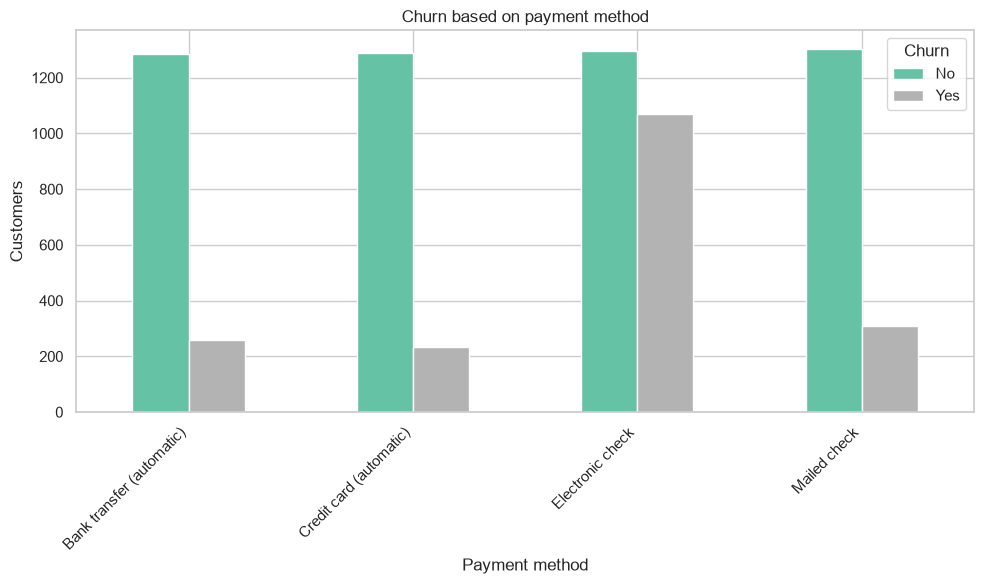

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pm_c = pd.crosstab(df['PaymentMethod'], df['Churn'])

pm_c.plot(kind='bar', figsize=(10,6), colormap='Set2')

plt.title('Churn based on payment method')
plt.xlabel('Payment method')
plt.ylabel('Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()

plt.show()

As we can see we have a huge Churn on the people using electronic checks

This is something we need to look deeper into. Who uses it and does we have any other things related to the "EC" customers

In [6]:
df_ec = df[df['PaymentMethod'] == 'Electronic check'].copy()

df_ec.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
14,5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No


In [7]:
df_ec.info()

<class 'pandas.DataFrame'>
Index: 2365 entries, 0 to 7040
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        2365 non-null   str    
 1   gender            2365 non-null   str    
 2   SeniorCitizen     2365 non-null   int64  
 3   Partner           2365 non-null   str    
 4   Dependents        2365 non-null   str    
 5   tenure            2365 non-null   int64  
 6   PhoneService      2365 non-null   str    
 7   MultipleLines     2365 non-null   str    
 8   InternetService   2365 non-null   str    
 9   OnlineSecurity    2365 non-null   str    
 10  OnlineBackup      2365 non-null   str    
 11  DeviceProtection  2365 non-null   str    
 12  TechSupport       2365 non-null   str    
 13  StreamingTV       2365 non-null   str    
 14  StreamingMovies   2365 non-null   str    
 15  Contract          2365 non-null   str    
 16  PaperlessBilling  2365 non-null   str    
 17  PaymentMeth

#### Electronic check:

contract vs churn

In [8]:
contract_churn = pd.crosstab(df_ec['Contract'], df_ec['Churn'], normalize='index') * 100
print(contract_churn)

print(pd.crosstab(df_ec['Contract'], df_ec['Churn']))

Churn                  No        Yes
Contract                            
Month-to-month  46.270270  53.729730
One year        81.556196  18.443804
Two year        92.261905   7.738095
Churn            No  Yes
Contract                
Month-to-month  856  994
One year        283   64
Two year        155   13


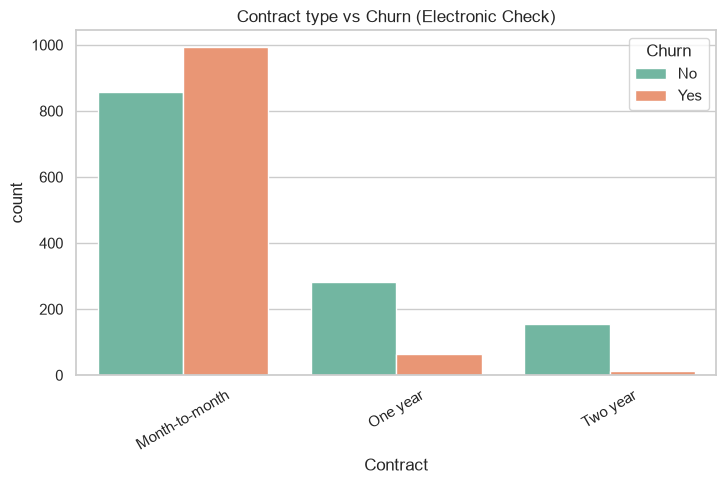

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 2)
sns.countplot(data=df_ec, x='Contract', hue='Churn', palette='Set2')
plt.title('Contract type vs Churn (Electronic Check)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

We can see that the group with highest churn is month-to-month

we will circel back to this to find out more. have to check tenure.

#### Electronic check:

monthly charge vs churn

In [10]:
mean_charges = df_ec.groupby('Churn')['MonthlyCharges'].mean()
print(mean_charges)

print(df_ec.groupby('Churn')['MonthlyCharges'].describe())

Churn
No     74.232032
Yes    78.700980
Name: MonthlyCharges, dtype: float64
        count       mean        std    min      25%    50%    75%     max
Churn                                                                    
No     1294.0  74.232032  26.094541  18.85  54.8625  79.80  94.75  118.65
Yes    1071.0  78.700980  21.083276  19.25  70.1500  81.95  94.60  117.45


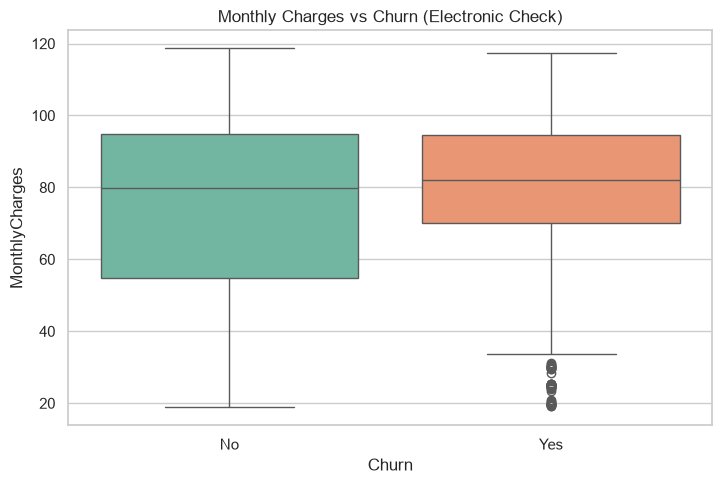

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_ec, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', legend=False)
plt.title('Monthly Charges vs Churn (Electronic Check)')

plt.tight_layout()
plt.show()

People with electronic billing that churn does so if them have over 70 or more in monthly payment

#### Electronic check:

seniors vs churn

I decided to check seniors after Oscar found a higher chance of churning if you're a senior

In [12]:
df_ec['SeniorLabel'] = df_ec['SeniorCitizen'].map({0: 'Non-senior', 1: 'Senior'})


senior_churn = pd.crosstab(df_ec['SeniorLabel'], df_ec['Churn'], normalize='index') * 100
print(senior_churn)

Churn               No        Yes
SeniorLabel                      
Non-senior   57.425184  42.574816
Senior       46.632997  53.367003


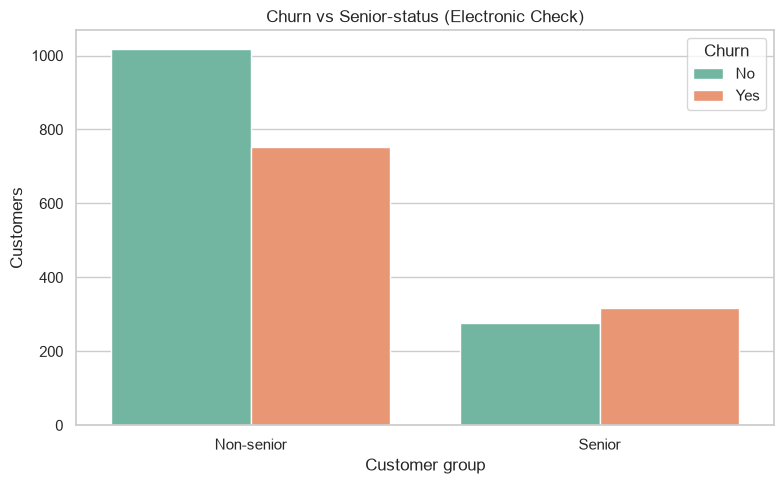

In [13]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df_ec, x='SeniorLabel', hue='Churn', palette='Set2', legend=True)
plt.title('Churn vs Senior-status (Electronic Check)')
plt.xlabel('Customer group')
plt.ylabel('Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

As we can see seniors are have over a 50% churn rate when using electronic check

we can asume that Seniors with electronic checks that have a high monthly cost and are month-to-moth customer will more then likely churn.

In [14]:
df_senior_echeck_mtm = df_ec[
    (df_ec['SeniorCitizen'] == 1) & 
    (df_ec['Contract'] == 'Month-to-month')
].copy()

print(df_senior_echeck_mtm['Churn'].value_counts(normalize=True) * 100)

Churn
Yes    59.259259
No     40.740741
Name: proportion, dtype: float64


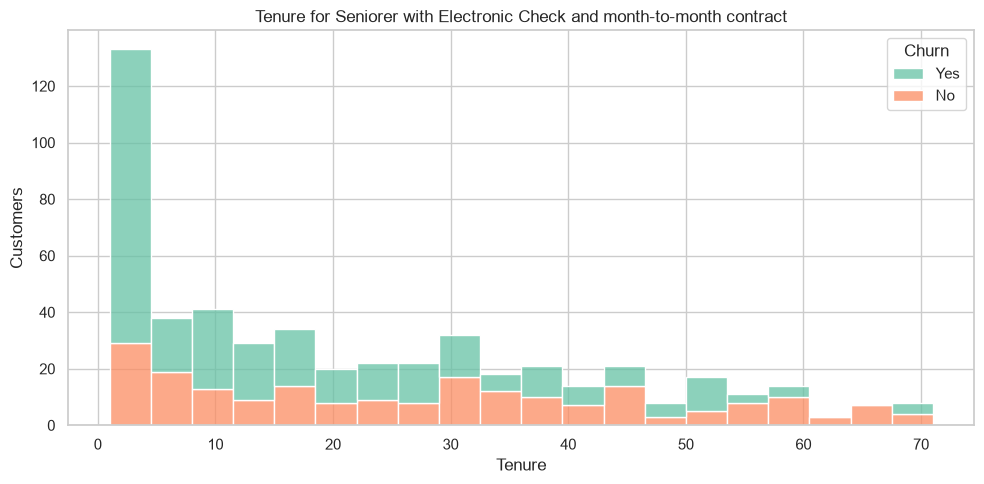

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_senior_echeck_mtm, x='tenure', hue='Churn', multiple='stack', palette='Set2', bins=20)
plt.title('Tenure for Seniorer with Electronic Check and month-to-month contract')
plt.xlabel('Tenure')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

After looking data we can see that seniors churn quickly when using electronic billing

# - EXCLUDING SENIOR CITIZENS DOWN BELOW - 

We'll exlcude senior citizens down below here to try to gain more insight

In [16]:
df_non_senior = df[df['SeniorCitizen'] == 0].copy()
df_non_senior['Churn_num'] = (df_non_senior['Churn'] == 'Yes').astype(int)

sns.set_theme(style="dark")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

## Churn rate by Payment Method

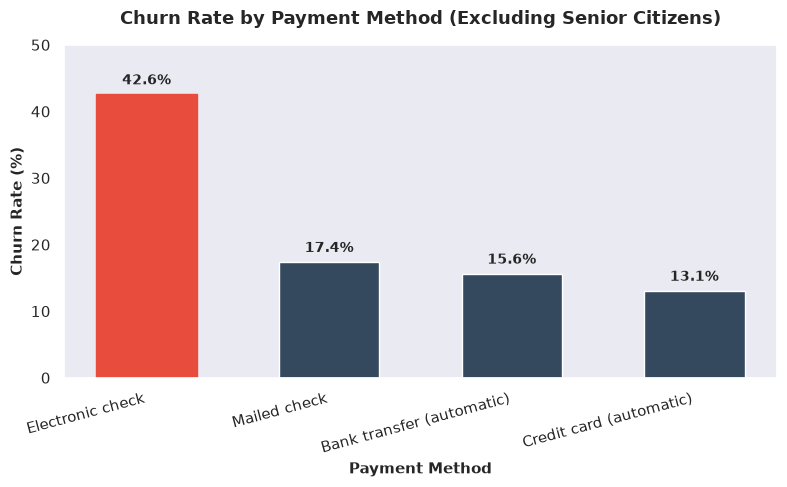

In [17]:
pm_df = df_non_senior.groupby('PaymentMethod')['Churn_num'].agg(
    total='count',
    churned='sum',
    churn_rate=lambda x: x.mean() * 100
).reset_index().sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(pm_df['PaymentMethod'], pm_df['churn_rate'], color='#34495e', width=0.55)
bars[0].set_color('#e74c3c') 

ax.set_title('Churn Rate by Payment Method (Excluding Senior Citizens)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Payment Method', fontsize=11, fontweight='bold')
ax.set_ylim(0, 50)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Conclusion

Even without senior citizens, the electronic check is still the worst culprit when it comes to churn rate

## Churn Rate by tenure group

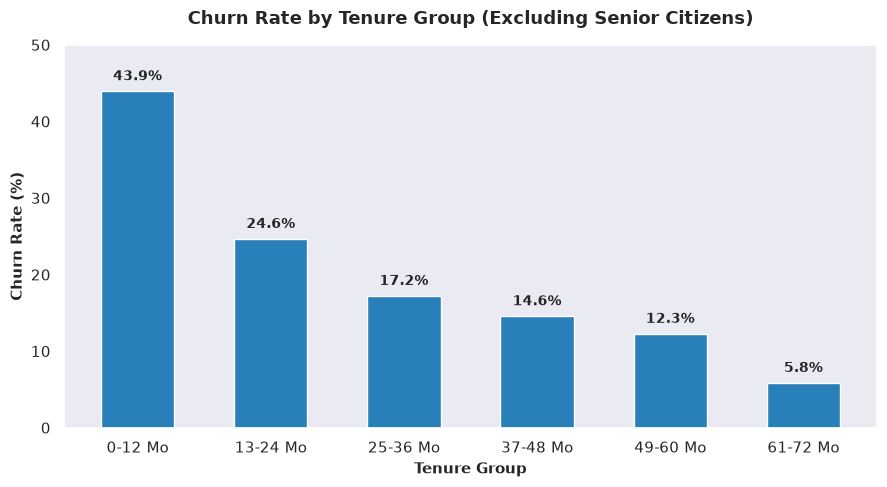

In [18]:
df_non_senior['tenure_group'] = pd.cut(
    df_non_senior['tenure'], 
    bins=[-1, 12, 24, 36, 48, 60, 72], 
    labels=['0-12 Mo', '13-24 Mo', '25-36 Mo', '37-48 Mo', '49-60 Mo', '61-72 Mo']
)

tenure_df = df_non_senior.groupby('tenure_group', observed=False)['Churn_num'].agg(
    total='count',
    churned='sum',
    churn_rate=lambda x: x.mean() * 100
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tenure_df['tenure_group'], tenure_df['churn_rate'], color='#2980b9', width=0.55)

ax.set_title('Churn Rate by Tenure Group (Excluding Senior Citizens)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Tenure Group', fontsize=11, fontweight='bold')
ax.set_ylim(0, 50)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Conclusion 

Most costumers churn within the first year, still matching to what it was without excluding senior citizens.

## Churn rate by monthly charges bracket

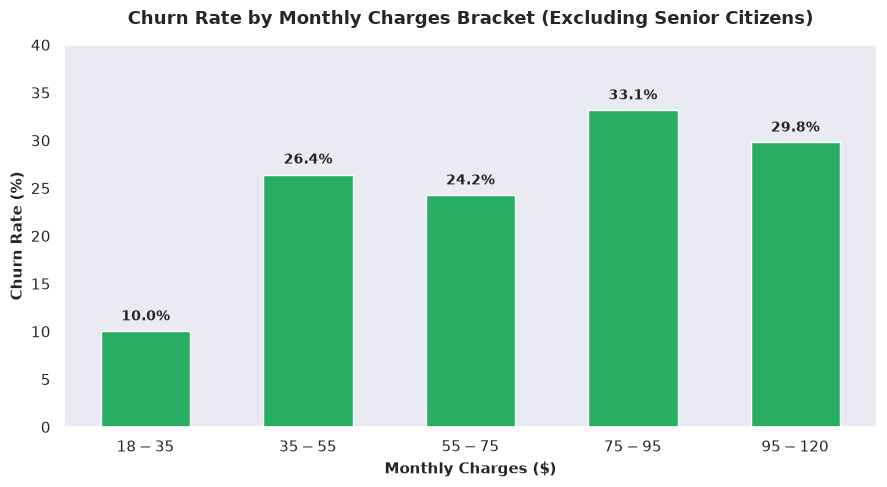

In [19]:
df_non_senior['monthly_charge_group'] = pd.cut(
    df_non_senior['MonthlyCharges'], 
    bins=[15, 35, 55, 75, 95, 120], 
    labels=['$18-$35', '$35-$55', '$55-$75', '$75-$95', '$95-$120']
)

mc_df = df_non_senior.groupby('monthly_charge_group', observed=False)['Churn_num'].agg(
    total='count',
    churned='sum',
    churn_rate=lambda x: x.mean() * 100
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(mc_df['monthly_charge_group'], mc_df['churn_rate'], color='#27ae60', width=0.55)

ax.set_title('Churn Rate by Monthly Charges Bracket (Excluding Senior Citizens)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 40)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Conclusion

Suprisingly, the most expensive option does not have highest of rate of churning. But 62.9% of all churns happen above the $75/month mark